In [1]:
import pandas as pd 
data = pd.read_csv('student_data.csv')
print(data)

   StudentID            Name Gender   Grade   Age   Subject  Score  \
0           1   Alice Smith        F      10   15      Math     88   
1           2    Brian Jones       M      10   16  Science      76   
2           3   Clara Brown        F      11   16      Math     92   
3           4    David Clark       M      12   17   History     65   
4           5  Ella Johnson        F      11   16   English     79   

   Attendance %  
0            95  
1            88  
2            98  
3            75  
4            85  


In [3]:
df = pd.read_csv('student_data.csv')
print(df.head()) 
print(df.info())        
print(df.isnull().sum())

   StudentID            Name Gender   Grade   Age   Subject  Score  \
0           1   Alice Smith        F      10   15      Math     88   
1           2    Brian Jones       M      10   16  Science      76   
2           3   Clara Brown        F      11   16      Math     92   
3           4    David Clark       M      12   17   History     65   
4           5  Ella Johnson        F      11   16   English     79   

   Attendance %  
0            95  
1            88  
2            98  
3            75  
4            85  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   StudentID     5 non-null      int64 
 1   Name          5 non-null      object
 2   Gender        5 non-null      object
 3   Grade         5 non-null      int64 
 4   Age           5 non-null      int64 
 5   Subject       5 non-null      object
 6   Score         5 non-null      

In [11]:
df = pd.read_csv('student_data.csv')
# 1. Display basic statistics for numerical columns
print("📊 Basic Statistics:\n")
print(df.describe())

# 2. Group by 'Subject' and compute average Score and Attendance
print("\n📚 Average Score and Attendance by Subject:\n")
print(df.groupby('Subject')[['Score', 'Attendance %']].mean().reset_index())

📊 Basic Statistics:

       StudentID     Grade         Age      Score  Attendance %
count    5.000000   5.00000   5.000000   5.000000      5.000000
mean     3.000000  10.80000  16.000000  80.000000     88.200000
std      1.581139   0.83666   0.707107  10.606602      9.038805
min      1.000000  10.00000  15.000000  65.000000     75.000000
25%      2.000000  10.00000  16.000000  76.000000     85.000000
50%      3.000000  11.00000  16.000000  79.000000     88.000000
75%      4.000000  11.00000  16.000000  88.000000     95.000000
max      5.000000  12.00000  17.000000  92.000000     98.000000

📚 Average Score and Attendance by Subject:

    Subject  Score  Attendance %
0   English   79.0          85.0
1   History   65.0          75.0
2      Math   90.0          96.5
3  Science    76.0          88.0


In [12]:
#Data visualization 
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 1. Line Chart: Score Trend Across Students (simulating time with StudentID)
plt.figure(figsize=(8, 4))
sns.lineplot(x='StudentID', y='Score', data=df, marker='o')
plt.title("📈 Score Trend Across Students")
plt.xlabel("StudentID")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1778/3447997052.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Subject', y='Score', data=df, ci=None)
/tmp/ipykernel_1778/3447997052.py:7: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


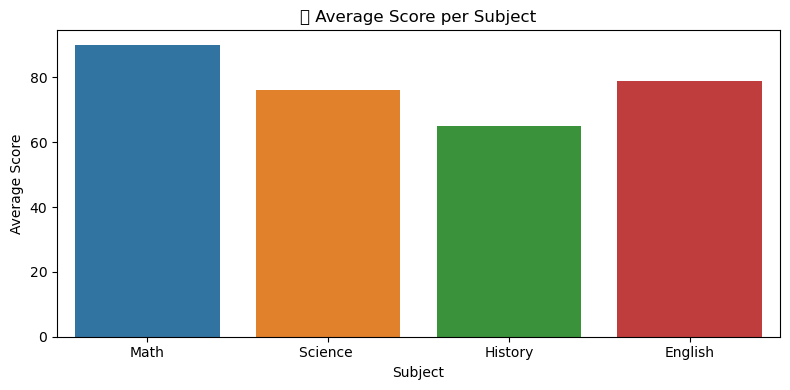

In [18]:
# 2. Bar Chart: Average Score by Subject
plt.figure(figsize=(8, 4))
sns.barplot(x='Subject', y='Score', data=df, ci=None)
plt.title("📊 Average Score per Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1778/4272333137.py:7: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  plt.tight_layout()
/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


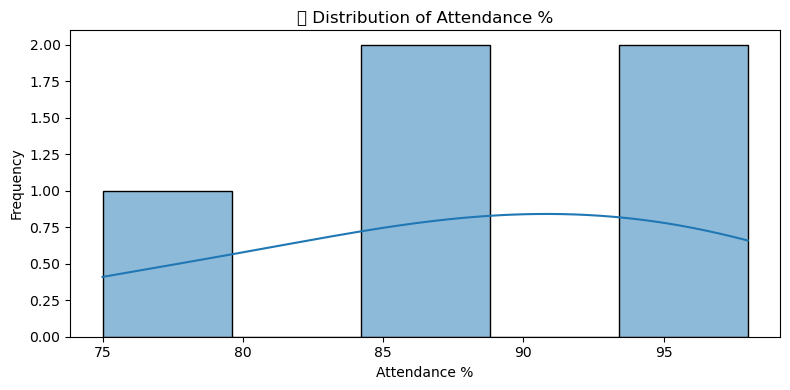

In [22]:
# 3. Histogram: Distribution of Attendance
plt.figure(figsize=(8, 4))
sns.histplot(df['Attendance %'], bins=5, kde=True)
plt.title("📉 Distribution of Attendance %")
plt.xlabel("Attendance %")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
# 4. Scatter Plot: Score vs. Attendance
plt.figure(figsize=(8, 4))
sns.scatterplot(x='Attendance %', y='Score', hue='Gender', style='Subject', data=df)
plt.title("🔍 Score vs. Attendance by Gender and Subject")
plt.xlabel("Attendance %")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

In [30]:
# Set Seaborn style
sns.set(style="whitegrid")


In [ ]:
import pandas as pd

try:
    # Try to load the CSV file
    df = pd.read_csv("student_scores.csv")

    # Display first few rows
    print("✅ Data loaded successfully:")
    print(df.head())

    # Clean column names (remove spaces)
    df.columns = df.columns.str.replace(' ', '')

    # Check for missing values
    if df.isnull().values.any():
        print("\n⚠️ Missing values found. Filling with 0...")
        df = df.fillna(0)  # You can also use dropna() if preferred

    # Convert Score column to numeric (in case of invalid entries)
    df['Score'] = pd.to_numeric(df['Score'], errors='coerce')
    if df['Score'].isnull().any():
        print("⚠️ Invalid scores found and set to NaN. Filling with average score.")
        df['Score'].fillna(df['Score'].mean(), inplace=True)

    print("\n✅ Cleaned Data:")
    print(df.info())

except FileNotFoundError:
    print("❌ Error: The file 'student_scores.csv' was not found.")
except pd.errors.ParserError:
    print("❌ Error: Could not parse the CSV file. Check formatting.")
except Exception as e:
    print(f"❌ Unexpected error: {e}")